# Revio — Preprocessing & Augmentation Pipeline

Demonstrates the full data pipeline from raw `.wav` files to augmented training-ready arrays.

**Sections**
1. Load all three datasets
2. Stratified 70 / 15 / 15 train-val-test split
3. Augment training split only (SpecAugment)
4. Shape and label-distribution verification
5. Save processed arrays to `data/processed/` for model notebooks

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

from src.preprocess import (
    load_braking_dataset,
    load_startup_dataset,
    load_idle_dataset,
    N_MFCC, DURATION, SAMPLE_RATE,
)
from src.augment import augment_dataset

PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
VAL_SIZE  = 0.15
TEST_SIZE = 0.15   # fraction of full dataset

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup complete.')

Setup complete.


## 1 — Load Datasets

In [2]:
print('=== Braking ===')
X_brk, y_brk, labels_brk = load_braking_dataset('data/raw')

print('\n=== Start-Up ===')
X_su, y_su, labels_su = load_startup_dataset('data/raw')

print('\n=== Idle ===')
X_idl, y_idl, labels_idl = load_idle_dataset('data/raw')

datasets = {
    'Braking':  (X_brk, y_brk, labels_brk),
    'Start-Up': (X_su,  y_su,  labels_su),
    'Idle':     (X_idl, y_idl, labels_idl),
}

print(f'\n{"State":<10} {"X shape":<22} {"Classes"}')
print('-' * 50)
for name, (X, y, labels) in datasets.items():
    print(f'{name:<10} {str(X.shape):<22} {labels}')

=== Braking ===
Loading Braking dataset from: data\raw\braking state
  [0] normal_brakes                    77 files
  [1] worn_out_brakes                  76 files

=== Start-Up ===
Loading Start-Up dataset from: data\raw\startup state
  [0] normal_engine_startup            61 files
  [1] bad_ignition                     62 files
  [2] dead_battery                     57 files

=== Idle ===
Loading Idle dataset from: data\raw\idle state
  [0] normal_engine_idle              264 files
  [1] low_oil                         107 files
  [2] power_steering                  129 files
  [3] serpentine_belt                 116 files

State      X shape                Classes
--------------------------------------------------
Braking    (153, 40, 78)          ['normal_brakes', 'worn_out_brakes']
Start-Up   (180, 40, 78)          ['normal_engine_startup', 'bad_ignition', 'dead_battery']
Idle       (616, 40, 78)          ['normal_engine_idle', 'low_oil', 'power_steering', 'serpentine_belt']


## 2 — Stratified 70 / 15 / 15 Split

In [3]:
def split_dataset(X, y, val_size=VAL_SIZE, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Stratified train / val / test split."""
    # First carve out the test set
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    # Val fraction relative to the remaining train+val pool
    val_fraction = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_fraction, stratify=y_tv, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


splits = {}
print(f'{"State":<10} {"Train":>6} {"Val":>6} {"Test":>6}  (70/15/15)')
print('-' * 42)
for name, (X, y, labels) in datasets.items():
    X_tr, X_v, X_te, y_tr, y_v, y_te = split_dataset(X, y)
    splits[name] = (X_tr, X_v, X_te, y_tr, y_v, y_te, labels)
    n = len(y)
    print(f'{name:<10} {len(y_tr):>6} {len(y_v):>6} {len(y_te):>6}  '
          f'({len(y_tr)/n:.0%}/{len(y_v)/n:.0%}/{len(y_te)/n:.0%})')

State       Train    Val   Test  (70/15/15)
------------------------------------------
Braking       107     23     23  (70%/15%/15%)
Start-Up      126     27     27  (70%/15%/15%)
Idle          430     93     93  (70%/15%/15%)


In [4]:
# Verify stratification — class proportions must be consistent across splits
for name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels) in splits.items():
    print(f'\n{name}')
    print(f'  {"Class":<28} {"Train":>6} {"Val":>6} {"Test":>6}')
    for i, lbl in enumerate(labels):
        tr_n = (y_tr == i).sum()
        v_n  = (y_v  == i).sum()
        te_n = (y_te == i).sum()
        print(f'  {lbl:<28} {tr_n:>6} {v_n:>6} {te_n:>6}')


Braking
  Class                         Train    Val   Test
  normal_brakes                    53     12     12
  worn_out_brakes                  54     11     11

Start-Up
  Class                         Train    Val   Test
  normal_engine_startup            43      9      9
  bad_ignition                     44      9      9
  dead_battery                     39      9      9

Idle
  Class                         Train    Val   Test
  normal_engine_idle              184     40     40
  low_oil                          75     16     16
  power_steering                   90     20     19
  serpentine_belt                  81     17     18


## 3 — Augment Training Split Only

In [5]:
AUG_MULTIPLIER = 2   # 2 augmented copies per original → 3× training set size

augmented = {}
print(f'{"State":<10} {"Before aug":>12} {"After aug":>11}  (val/test unchanged)')
print('-' * 52)
for name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels) in splits.items():
    X_tr_aug, y_tr_aug = augment_dataset(
        X_tr, y_tr, multiplier=AUG_MULTIPLIER, seed=RANDOM_STATE
    )
    augmented[name] = (X_tr_aug, X_v, X_te, y_tr_aug, y_v, y_te, labels)
    print(f'{name:<10} {str(X_tr.shape):>12}  →  {str(X_tr_aug.shape):<20}')

print(f'\nVal and test splits are untouched.')

State        Before aug   After aug  (val/test unchanged)
----------------------------------------------------
Braking    (107, 40, 78)  →  (321, 40, 78)       
Start-Up   (126, 40, 78)  →  (378, 40, 78)       
Idle       (430, 40, 78)  →  (1290, 40, 78)      

Val and test splits are untouched.


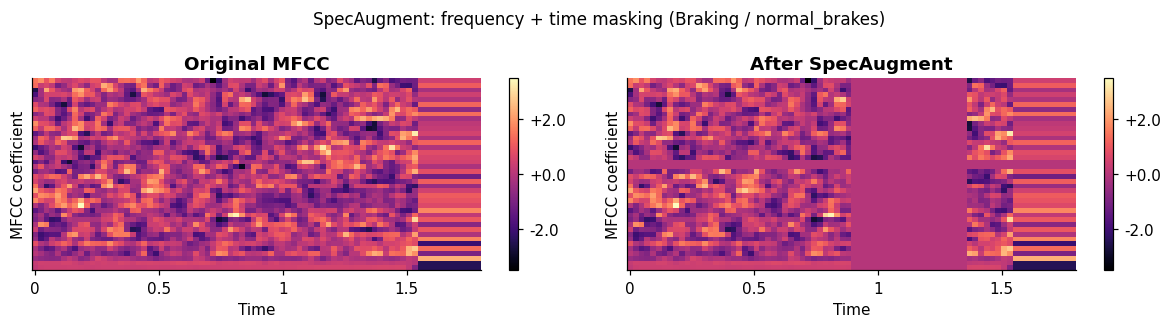

Saved → results/specaugment_example.png


In [6]:
# Visual check — SpecAugment effect on one Braking MFCC
import librosa.display
from src.augment import spec_augment

X_tr_brk = splits['Braking'][0]
sample = X_tr_brk[0]   # shape (40, 78)
aug    = spec_augment(sample, num_freq_masks=1, num_time_masks=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, data, title in zip(axes, [sample, aug], ['Original MFCC', 'After SpecAugment']):
    img = librosa.display.specshow(
        data, sr=SAMPLE_RATE, hop_length=512, x_axis='time', ax=ax, cmap='magma'
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('MFCC coefficient')
    fig.colorbar(img, ax=ax, format='%+.1f')

plt.suptitle('SpecAugment: frequency + time masking (Braking / normal_brakes)', fontsize=11)
plt.tight_layout()
plt.savefig('results/specaugment_example.png', bbox_inches='tight')
plt.show()
print('Saved → results/specaugment_example.png')

## 4 — Shape & Distribution Verification

In [7]:
print('Final shapes going into training:\n')
print(f'{"State":<10} {"Split":<6} {"Shape":<24} {"dtype"}')
print('-' * 55)
for name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels) in augmented.items():
    for split_name, X, y in [("train", X_tr, y_tr), ("val", X_v, y_v), ("test", X_te, y_te)]:
        print(f'{name:<10} {split_name:<6} {str(X.shape):<24} {X.dtype}')
    print()

Final shapes going into training:

State      Split  Shape                    dtype
-------------------------------------------------------
Braking    train  (321, 40, 78)            float32
Braking    val    (23, 40, 78)             float32
Braking    test   (23, 40, 78)             float32

Start-Up   train  (378, 40, 78)            float32
Start-Up   val    (27, 40, 78)             float32
Start-Up   test   (27, 40, 78)             float32

Idle       train  (1290, 40, 78)           float32
Idle       val    (93, 40, 78)             float32
Idle       test   (93, 40, 78)             float32



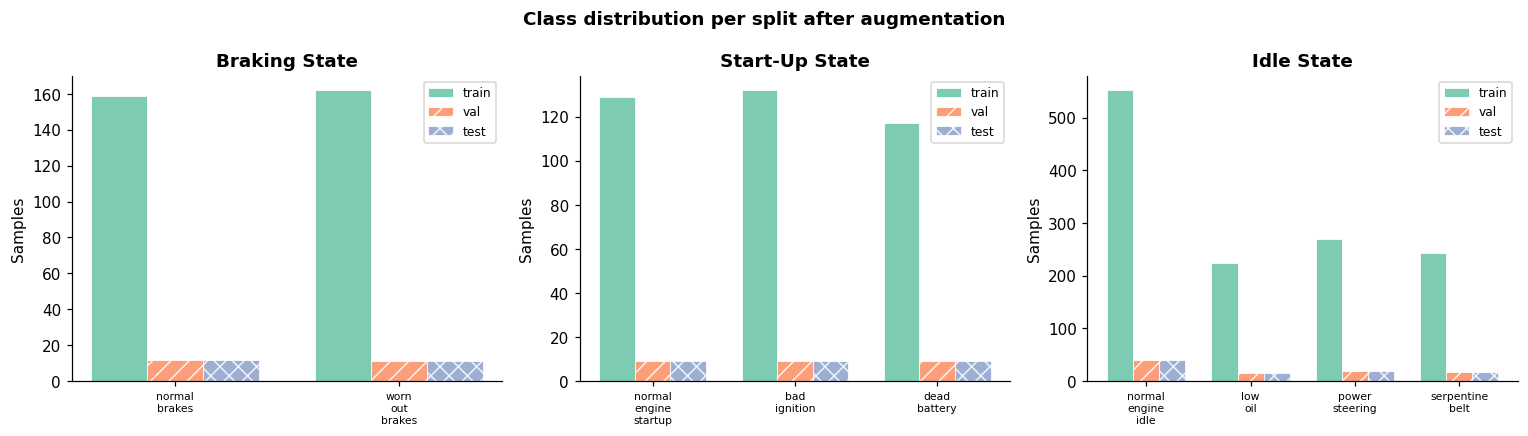

Saved → results/split_distribution.png


In [8]:
# Class balance after augmentation (augment_dataset preserves proportions)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = plt.cm.Set2.colors
bar_w  = 0.25

for ax, (name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels)) in zip(axes, augmented.items()):
    n_classes = len(labels)
    x = np.arange(n_classes)
    for j, (split_name, y_split, hatch) in enumerate(
        [('train', y_tr, ''), ('val', y_v, '//'), ('test', y_te, 'xx')]
    ):
        counts = [(y_split == i).sum() for i in range(n_classes)]
        ax.bar(x + (j - 1) * bar_w, counts, bar_w,
               label=split_name, color=colors[j], hatch=hatch,
               edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace('_', '\n') for l in labels], fontsize=7)
    ax.set_title(f'{name} State', fontweight='bold')
    ax.set_ylabel('Samples')
    ax.legend(fontsize=8)

fig.suptitle('Class distribution per split after augmentation', fontweight='bold')
plt.tight_layout()
plt.savefig('results/split_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → results/split_distribution.png')

## 5 — Save Processed Arrays

In [9]:
# Save as .npz — one file per state, contains all splits + label names
key_map = {
    'Braking':  'braking',
    'Start-Up': 'startup',
    'Idle':     'idle',
}

for name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels) in augmented.items():
    out_path = PROCESSED_DIR / f'{key_map[name]}.npz'
    np.savez(
        out_path,
        X_train=X_tr, y_train=y_tr,
        X_val=X_v,   y_val=y_v,
        X_test=X_te, y_test=y_te,
        label_names=np.array(labels),
    )
    size_mb = out_path.stat().st_size / 1e6
    print(f'Saved {out_path}  ({size_mb:.2f} MB)')

print('\nAll arrays saved to data/processed/')

Saved data\processed\braking.npz  (4.58 MB)
Saved data\processed\startup.npz  (5.40 MB)
Saved data\processed\idle.npz  (18.43 MB)

All arrays saved to data/processed/


In [10]:
# Round-trip verification — reload and confirm shapes match
print('Round-trip check:\n')
for fname in sorted(PROCESSED_DIR.glob('*.npz')):
    data = np.load(fname, allow_pickle=True)
    print(f'{fname.name}')
    for key in ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']:
        print(f'  {key:<10} {str(data[key].shape)}')
    print(f'  labels     {list(data["label_names"])}')
    print()

Round-trip check:

braking.npz
  X_train    (321, 40, 78)
  X_val      (23, 40, 78)
  X_test     (23, 40, 78)
  y_train    (321,)
  y_val      (23,)
  y_test     (23,)
  labels     [np.str_('normal_brakes'), np.str_('worn_out_brakes')]

idle.npz
  X_train    (1290, 40, 78)
  X_val      (93, 40, 78)
  X_test     (93, 40, 78)
  y_train    (1290,)
  y_val      (93,)
  y_test     (93,)
  labels     [np.str_('normal_engine_idle'), np.str_('low_oil'), np.str_('power_steering'), np.str_('serpentine_belt')]

startup.npz
  X_train    (378, 40, 78)
  X_val      (27, 40, 78)
  X_test     (27, 40, 78)
  y_train    (378,)
  y_val      (27,)
  y_test     (27,)
  labels     [np.str_('normal_engine_startup'), np.str_('bad_ignition'), np.str_('dead_battery')]

